In [9]:
!pip install torch_snippets
from torch_snippets import *
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
from torchvision import datasets
import torch
data_folder = '~/cifar10/cifar/'
datasets.CIFAR10(data_folder, download=True)  # baixa o CIFAR-10


100%|██████████| 170M/170M [34:53<00:00, 81.4kB/s]


Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /root/cifar10/cifar/
    Split: Train

In [3]:
class Colorize(torchvision.datasets.CIFAR10):  # classe de conjunto de dados personalizada
  def __init__(seçf, root, train):
    super().__init__(root, train)

  def __getitem__(self, ix):
    im, _ = super().__getitem__(ix)
    bw = im.convert('L').convert('RGB')  #converte a imagem de entrada para escala de cinza
    bw, im = np.array(bw)/255., np.array(im)/255.
    bw, im = [torch.tensor(i).permute(2,0,1).to(device).float() for i in [bw,im]]
    return bw, im

# conjuntos de dados de treinamento e validação
trn_ds = Colorize('~/cifar10/cifar/', train=True)
val_ds = Colorize('~/cifar10/cifar/', train=False)

trn_dl = DataLoader(trn_ds, batch_size=256, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=256, shuffle=False)

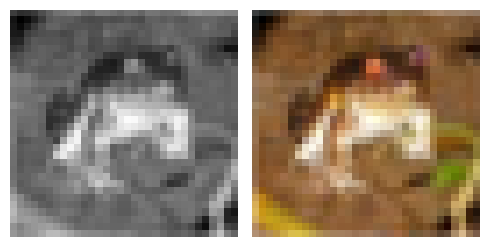

In [10]:
a,b = trn_ds[0]
subplots([a,b], nc=2)  # mostra lado a lado a versão preto e branco e a colorida original

In [11]:
# 3 classes para criar a arquitetura da unidade
class Identity(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return x

class DownConv(nn.Module): #descendente da unidade
    def __init__(self, ni, no, maxpool=True):
        super().__init__()
        self.model = nn.Sequential(
            nn.MaxPool2d(2) if maxpool else Identity(),
            nn.Conv2d(ni, no, 3, padding=1),
            nn.BatchNorm2d(no),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(no, no, 3, padding=1),
            nn.BatchNorm2d(no),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.model(x)

class UpConv(nn.Module): #ascendente da unidade
    def __init__(self, ni, no):
        super().__init__()
        self.convtranspose = nn.ConvTranspose2d(ni, no, 2, stride=2)
        self.convlayers = nn.Sequential(
            nn.Conv2d(no+no, no, 3, padding=1),
            nn.BatchNorm2d(no),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(no, no, 3, padding=1),
            nn.BatchNorm2d(no),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x, y):
        x = self.convtranspose(x)
        x = torch.cat([x, y], axis=1)
        x = self.convlayers(x)
        return x


class UNet(nn.Module): #estende o módulo e cria a arquitetura completa
    def __init__(self):
        super().__init__()
        #criação instâncias das classes
        self.d1 = DownConv(3, 64, maxpool=False)
        self.d2 = DownConv(64, 128)
        self.d3 = DownConv(128, 256)
        self.d4 = DownConv(256, 512)
        self.d5 = DownConv(512, 1024)

        self.u5 = UpConv(1024, 512)
        self.u4 = UpConv(512, 256)
        self.u3 = UpConv(256, 128)
        self.u2 = UpConv(128, 64)

        self.u1 = nn.Conv2d(64, 3, kernel_size=1, stride=1)


    def forward(self, x): #método para criar a unidade completa
        x0 = self.d1(x)
        x1 = self.d2(x0)
        x2 = self.d3(x1)
        x3 = self.d4(x2)
        x4 = self.d5(x3)

        X4 = self.u5(x4, x3)
        X3 = self.u4(X4, x2)
        X2 = self.u3(X3, x1)
        X1 = self.u2(X2, x0)
        X0 = self.u1(X1)

        return X0

In [12]:

def get_model(): # é criado uma instancia da classe
    model = UNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    return model, optimizer, loss_fn # é retornado a função de perda de unidade e o otimizador

In [13]:
def train_batch(model, data, optimizer, criterion):
    model.train()
    x, y = data
    _y = model(x)
    optimizer.zero_grad()
    loss = criterion(_y, y)
    loss.backward()
    optimizer.step()
    return loss.item() # calcula a perda e retorna

@torch.no_grad()
def validate_batch(model, data, criterion): # faz a validação  para cada lote
    model.eval()
    x, y = data
    _y = model(x)
    loss = criterion(_y, y)
    return loss.item()

EPOCH: 0.255  trn_loss: 0.008  (1757.17s - 687053.75s remaining)

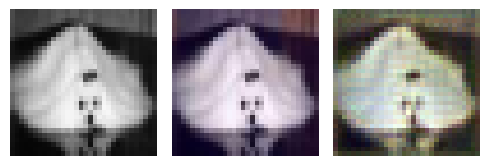

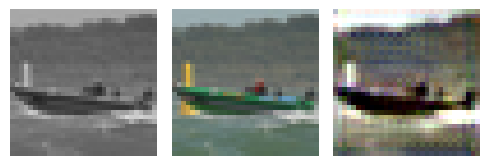

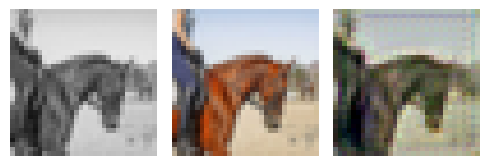

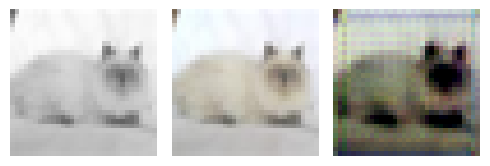

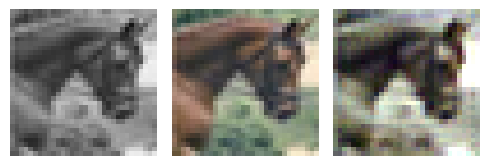

EPOCH: 0.505  trn_loss: 0.007  (3465.37s - 682607.68s remaining)

EPOCH: 0.510  trn_loss: 0.006  (3500.21s - 682540.10s remaining)

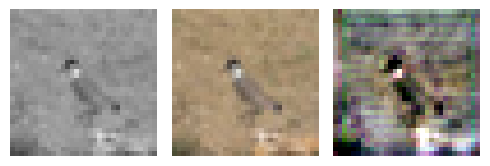

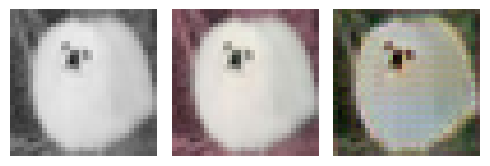

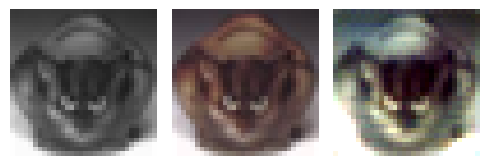

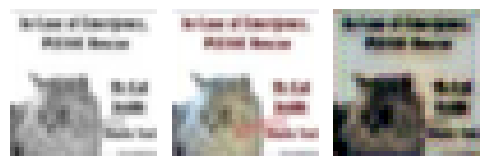

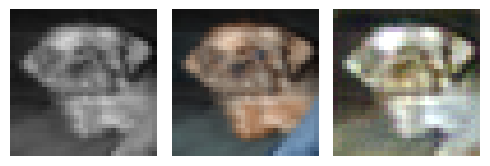

EPOCH: 0.760  trn_loss: 0.006  (5193.83s - 678021.15s remaining)

EPOCH: 0.765  trn_loss: 0.005  (5227.81s - 677872.79s remaining)

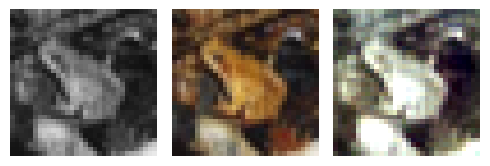

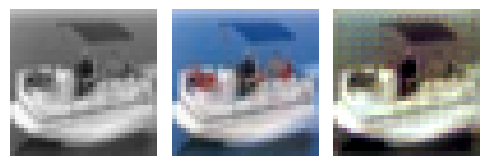

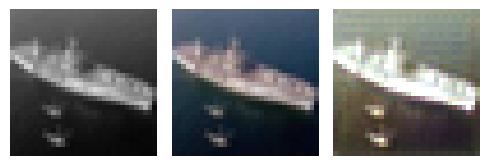

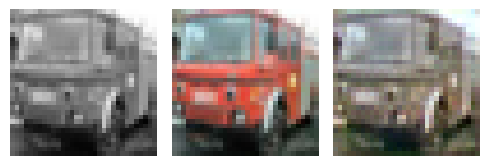

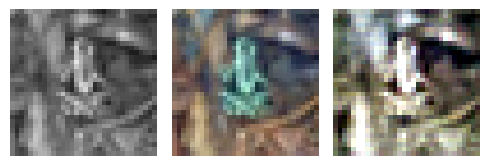

EPOCH: 0.975  val_loss: 0.007  (7163.05s - 727508.32s remaining)

EPOCH: 1.000  val_loss: 0.005  (7163.65s - 709201.20s remaining)

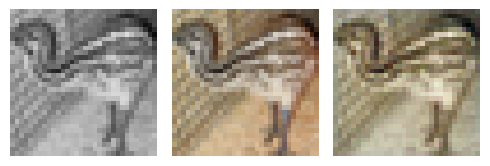

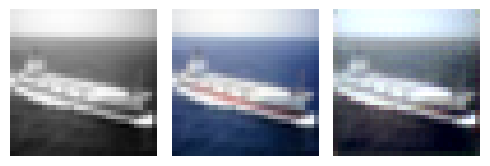

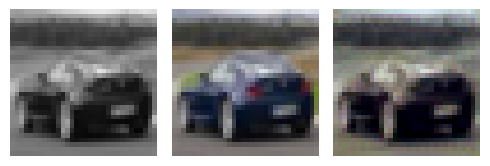

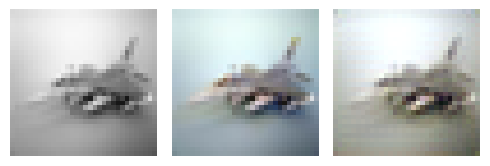

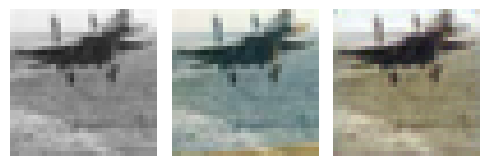

EPOCH: 1.250  trn_loss: 0.006  (8867.69s - 700547.18s remaining)

EPOCH: 1.255  trn_loss: 0.006  (8902.90s - 700433.78s remaining)

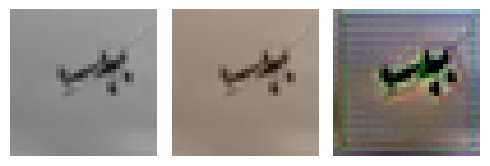

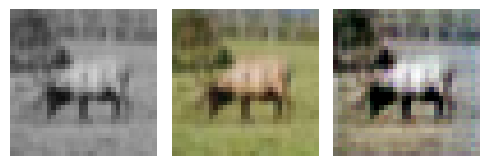

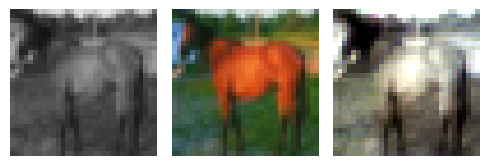

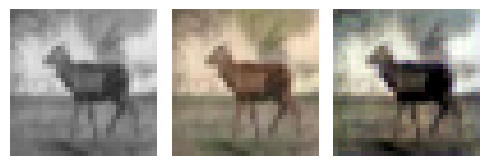

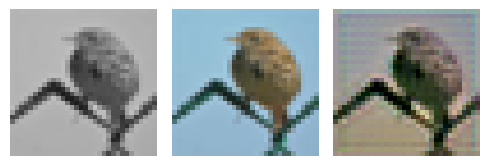

EPOCH: 1.505  trn_loss: 0.005  (10600.80s - 693723.69s remaining)

EPOCH: 1.510  trn_loss: 0.005  (10636.61s - 693679.63s remaining)

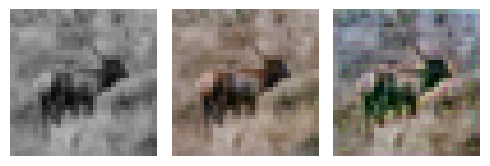

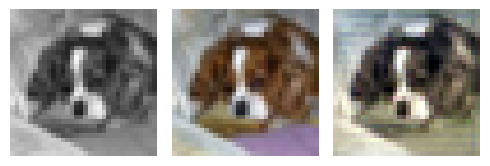

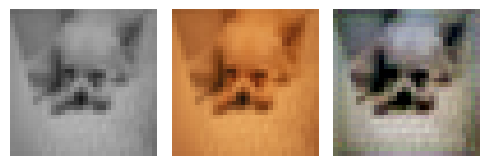

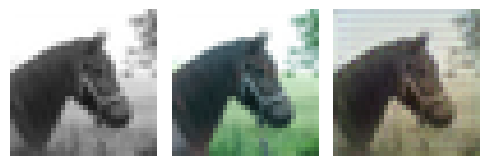

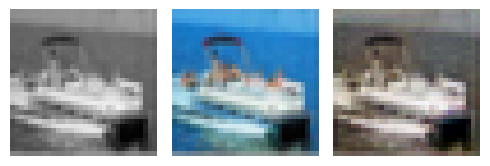

EPOCH: 1.617  trn_loss: 0.006  (11372.95s - 691812.68s remaining)

In [ ]:
model, optimizer, criterion = get_model()
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

_val_dl = DataLoader(val_ds, batch_size=1, shuffle=True) #utiliza o Dataloader para teste

n_epochs = 100 # são usados 100 epocas para treinamento
log = Report(n_epochs)
for ex in range(n_epochs):
    N = len(trn_dl)
    for bx, data in enumerate(trn_dl):
        loss = train_batch(model, data, optimizer, criterion)
        log.record(ex+(bx+1)/N, trn_loss=loss, end='\r') # faz o treinamento e armazeno o erro
        if (bx+1)%50 == 0:
            for _ in range(5):
                a,b = next(iter(_val_dl))
                _b = model(a)
                subplots([a[0], b[0], _b[0]], nc=3, figsize=(5,5)) #pega o input real e a previsão

    N = len(val_dl)
    for bx, data in enumerate(val_dl):
        loss = validate_batch(model, data, criterion)
        log.record(ex+(bx+1)/N, val_loss=loss, end='\r')

    exp_lr_scheduler.step() #faz atualizacao do aprendizado
    if (ex+1) % 5 == 0: log.report_avgs(ex+1)

    for _ in range(5):
        a,b = next(iter(_val_dl))
        _b = model(a) #realiza a previsao
        subplots([a[0], b[0], _b[0]], nc=3, figsize=(5,5))

log.plot(log=True)